In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/ModerateDemented/e93f9de2-fdb9-40d6-9796-63d1fa7eaba5.jpg
/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/ModerateDemented/ef0fc865-7e80-436a-a058-2b1d99af06fb.jpg
/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/ModerateDemented/aug_9709_26d7545e-6f95-44b3-b08b-05e8e4d6a72d.jpg
/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/ModerateDemented/aa28cd03-eeca-4dbf-a4f7-8ee3622618a7.jpg
/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/ModerateDemented/aug_7175_8658e2a3-a6d0-4224-a901-1478720f8d49.jpg
/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/ModerateDemented/aug_9973_moderateDem36.jpg
/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images/ModerateDemented/7ad437b5-641c-40ad-9a89-e7431fc48899.jpg
/kaggle/input/alzheimers-multi

In [29]:
# Required imports
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import cv2

# Data directory path
data_dir = '/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented/combined_images'
img_height, img_width = 224, 224
batch_size = 32

# Function to preprocess a single image
def preprocess_image(image):
    image = image.numpy()  # Convert tensor to numpy array
    # Convert to grayscale
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    # Normalize the image
    image = (image - np.min(image)) / (np.max(image) - np.min(image))
    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(np.uint8(image * 255))
    # Denoise using median blur
    image = cv2.medianBlur(image, 3)
    # Skull stripping (simplified thresholding)
    thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    # Standardize to 3 channels
    image = np.stack((image,) * 3, axis=-1)
    return image

# Function to preprocess the entire dataset
def preprocess_data(dataset):
    processed_images = []
    processed_labels = []
    for images, labels in dataset:
        for image in images:
            processed_images.append(preprocess_image(image))
        processed_labels.append(labels.numpy())
    return np.array(processed_images), np.array(processed_labels)

# Load the dataset
dataset = image_dataset_from_directory(
    data_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

# Split the dataset
train_size = int(0.7 * len(dataset))
valid_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - valid_size

train_data = dataset.take(train_size)
remaining = dataset.skip(train_size)
valid_data = remaining.take(valid_size)
test_data = remaining.skip(valid_size)

# Preprocess datasets
train_images, train_labels = preprocess_data(train_data)
valid_images, valid_labels = preprocess_data(valid_data)
test_images, test_labels = preprocess_data(test_data)

# Verify the preprocessed data
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)


Found 44000 files belonging to 4 classes.
Train images shape: (30784, 224, 224, 3)
Train labels shape: (962, 32, 4)


In [43]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping

# Create and compile a model
def create_model(base_model, num_classes):
    """Creates and compiles a model using a pre-trained base model."""
    base_model.trainable = False  # Freeze the base model's layers

    # Add new classification layers
    x = Dropout(0.3)(base_model.output)
    x = Flatten()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(num_classes, activation='softmax')(x)  # Output layer
    
    # Create the final model
    model = Model(inputs=base_model.input, outputs=outputs)
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate= 1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [36]:
# 1. VGG16
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
vgg16_model = create_model(base_model_vgg16, num_classes=len(class_names))  # Use len(class_names)

In [37]:
# Summary of the model
vgg16_model.summary()

# Train the model
history = vgg16_model.fit(
    train_data,
    epochs=25,
    batch_size=32,
    validation_data=valid_data,
)

# Evaluate the model on the test set
test_accuracy = vgg16_model.evaluate(test_data, verbose=0)
print(f'Test accuracy: {test_accuracy[1]}')

# Save the model
vgg16_model.save('vgg16_classification_model.h5')

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 16,320,644 (62.26 MB)

 Trainable params: 1,605,956 (6.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 205s 211ms/step - accuracy: 0.3151 - loss: 7.1945 - val_accuracy: 0.2916 - val_loss: 1.3399
Epoch 2/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 200s 207ms/step - accuracy: 0.3582 - loss: 1.4489 - val_accuracy: 0.4143 - val_loss: 1.2099
Epoch 3/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 199s 207ms/step - accuracy: 0.4346 - loss: 1.2320 - val_accuracy: 0.5507 - val_loss: 0.9573
Epoch 4/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 201s 209ms/step - accuracy: 0.5139 - loss: 1.0413 - val_accuracy: 0.6080 - val_loss: 0.8351
Epoch 5/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 199s 207ms/step - accuracy: 0.5643 - loss: 0.9244 - val_accuracy: 0.6282 - val_loss: 0.7774
Epoch 6/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 200s 208ms/step - accuracy: 0.5856 - loss: 0.8589 - val_accuracy: 0.6456 - val_loss: 0.7374
Epoch 7/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 200s 208ms/step - accuracy: 0.6000 - loss: 0.8219 - val_accuracy: 0.6570 - val_loss: 0.7134
Epoch 8/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 200s 208ms/step - accuracy: 0.6181 -

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# class names
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Step 1: Predict on the test set
y_true = []
y_pred = []

# Extract true labels and predicted labels
for images, labels in test_data:
    predictions = vgg16_model.predict(images) 
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer labels
    y_pred.extend(np.argmax(predictions, axis=1))    # Get predicted class

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Step 2: Generate classification report
class_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
)
print("Classification Report:\n")
print(class_report)
# Step 3: Accuracy Metric
accuracy = np.sum(y_true == y_pred) / len(y_true)
print(f"Overall Accuracy: {accuracy:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━

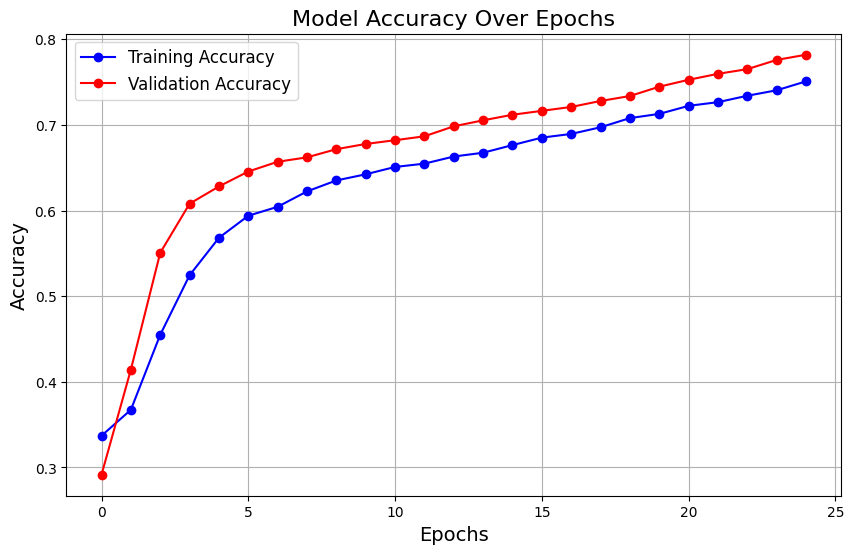

In [39]:
import matplotlib.pyplot as plt
# Plot the accuracy graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', marker='o')
plt.title('Model Accuracy Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

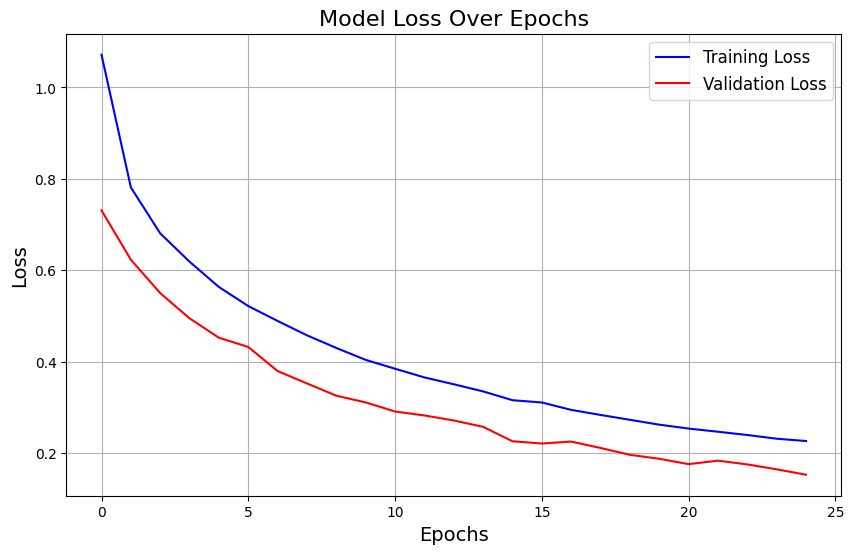

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [41]:
# 2. ResNet50
base_model_ResNet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
ResNet50_model = create_model(base_model_ResNet50, num_classes=len(class_names))  # Use len(class_names)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [42]:
# Summary of the model
ResNet50_model.summary()

# Train the model
history = ResNet50_model.fit(
    train_data,
    epochs=25,
    batch_size=32,
    validation_data=valid_data,
)

# Evaluate the model on the test set
test_accuracy = ResNet50_model.evaluate(test_data, verbose=0)
print(f'Test accuracy: {test_accuracy[1]}')

# Save the model
ResNet50_model.save('ResNet50_classification_model.h5')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 30,010,564 (114.48 MB)

 Trainable params: 6,422,852 (24.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 127s 121ms/step - accuracy: 0.4641 - loss: 1.3172 - val_accuracy: 0.6928 - val_loss: 0.6866
Epoch 2/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 124s 129ms/step - accuracy: 0.6595 - loss: 0.7429 - val_accuracy: 0.7448 - val_loss: 0.5924
Epoch 3/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 129s 134ms/step - accuracy: 0.7115 - loss: 0.6401 - val_accuracy: 0.7822 - val_loss: 0.5215
Epoch 4/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 130s 135ms/step - accuracy: 0.7471 - loss: 0.5708 - val_accuracy: 0.8099 - val_loss: 0.4616
Epoch 5/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 130s 135ms/step - accuracy: 0.7847 - loss: 0.5060 - val_accuracy: 0.8316 - val_loss: 0.4173
Epoch 6/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 131s 136ms/step - accuracy: 0.8091 - loss: 0.4515 - val_accuracy: 0.8513 - val_loss: 0.3878
Epoch 7/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 129s 135ms/step - accuracy: 0.8290 - loss: 0.4129 - val_accuracy: 0.8639 - val_loss: 0.3565
Epoch 8/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 129s 134ms/step - accuracy: 0.8478 -

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# class names
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Step 1: Predict on the test set
y_true = []
y_pred = []

# Extract true labels and predicted labels
for images, labels in test_data:
    predictions = ResNet50_model.predict(images) 
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer labels
    y_pred.extend(np.argmax(predictions, axis=1))    # Get predicted class

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Step 2: Generate classification report
class_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
)
print("Classification Report:\n")
print(class_report)
# Step 3: Accuracy Metric
accuracy = np.sum(y_true == y_pred) / len(y_true)
print(f"Overall Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━

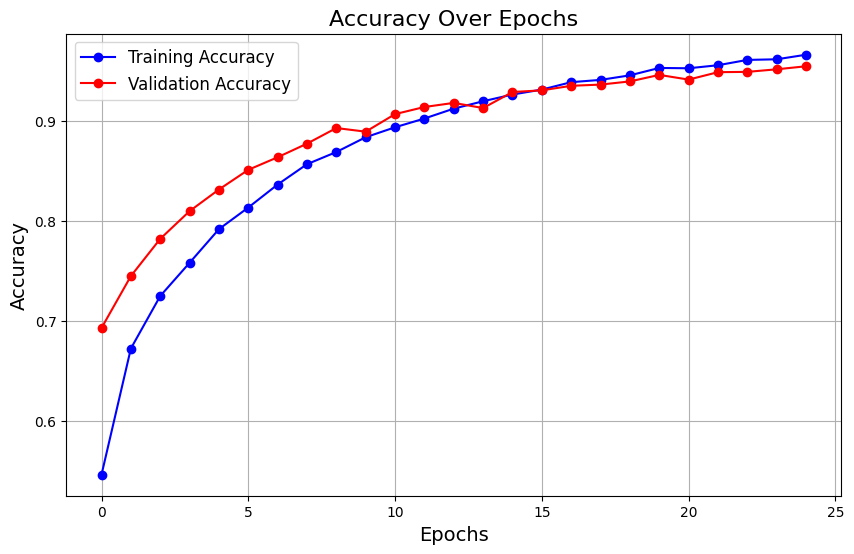

In [45]:
# Plot the accuracy graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', marker='o')
plt.title('Accuracy Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

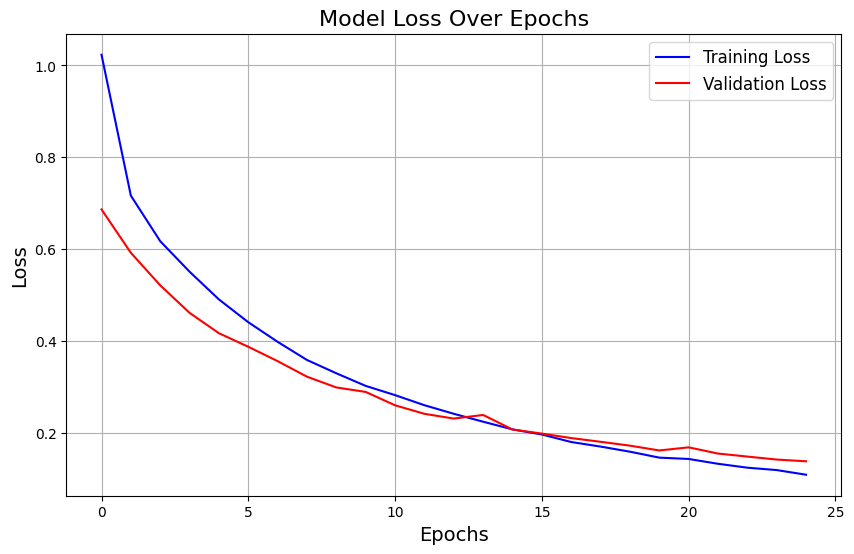

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [47]:
# 3. EfficientNetB0
base_model_EfficientNetB0 = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))
EfficientNetB0_model = create_model(base_model_EfficientNetB0, num_classes=len(class_names))  # Use len(class_names)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [48]:
# Summary of the model
EfficientNetB0_model.summary()

# Train the model
history = EfficientNetB0_model.fit(
    train_data,
    epochs=25,
    batch_size=32,
    validation_data=valid_data,
)

# Evaluate the model on the test set
test_accuracy = EfficientNetB0_model.evaluate(test_data, verbose=0)
print(f'Test accuracy: {test_accuracy[1]}')

# Save the model
EfficientNetB0_model.save('EfficientNetB0_classification_model.h5')

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 8,063,975 (30.76 MB)

 Trainable params: 4,014,404 (15.31 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 78s 60ms/step - accuracy: 0.4301 - loss: 1.2878 - val_accuracy: 0.6966 - val_loss: 0.7311
Epoch 2/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.6377 - loss: 0.8163 - val_accuracy: 0.7312 - val_loss: 0.6232
Epoch 3/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.6951 - loss: 0.6968 - val_accuracy: 0.7753 - val_loss: 0.5501
Epoch 4/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 54s 56ms/step - accuracy: 0.7241 - loss: 0.6343 - val_accuracy: 0.8005 - val_loss: 0.4950
Epoch 5/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 54s 56ms/step - accuracy: 0.7549 - loss: 0.5742 - val_accuracy: 0.8228 - val_loss: 0.4526
Epoch 6/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.7780 - loss: 0.5282 - val_accuracy: 0.8248 - val_loss: 0.4324
Epoch 7/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 55s 57ms/step - accuracy: 0.7918 - loss: 0.4999 - val_accuracy: 0.8613 - val_loss: 0.3797
Epoch 8/25
962/962 ━━━━━━━━━━━━━━━━━━━━ 55s 57ms/step - accuracy: 0.8052 - loss: 0.4696 - 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# class names
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# Step 1: Predict on the test set
y_true = []
y_pred = []

# Extract true labels and predicted labels
for images, labels in test_data:
    predictions = EfficientNetB0_model.predict(images) 
    y_true.extend(np.argmax(labels.numpy(), axis=1))  # Convert one-hot to integer labels
    y_pred.extend(np.argmax(predictions, axis=1))    # Get predicted class

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Step 2: Generate classification report
class_report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
)
print("Classification Report:\n")
print(class_report)
# Step 3: Accuracy Metric
accuracy = np.sum(y_true == y_pred) / len(y_true)
print(f"Overall Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━

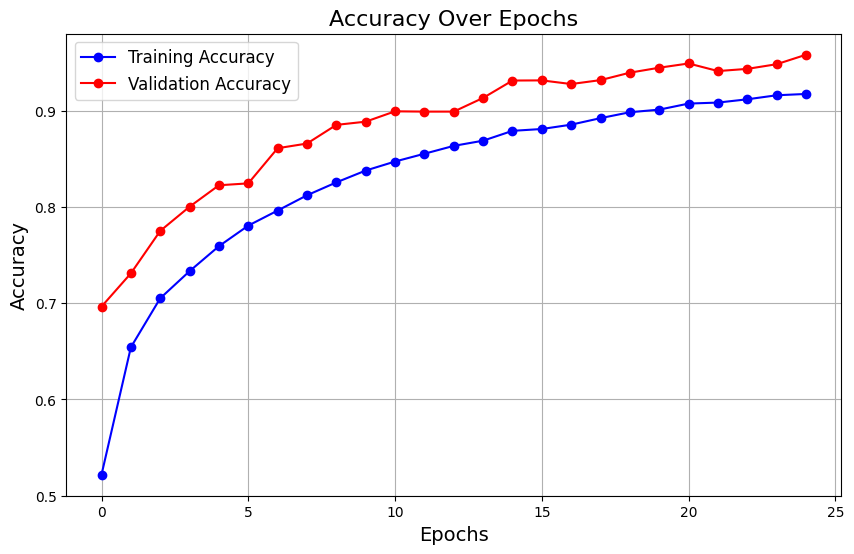

In [ ]:
# Plot the accuracy graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', marker='o')
plt.title('Accuracy Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

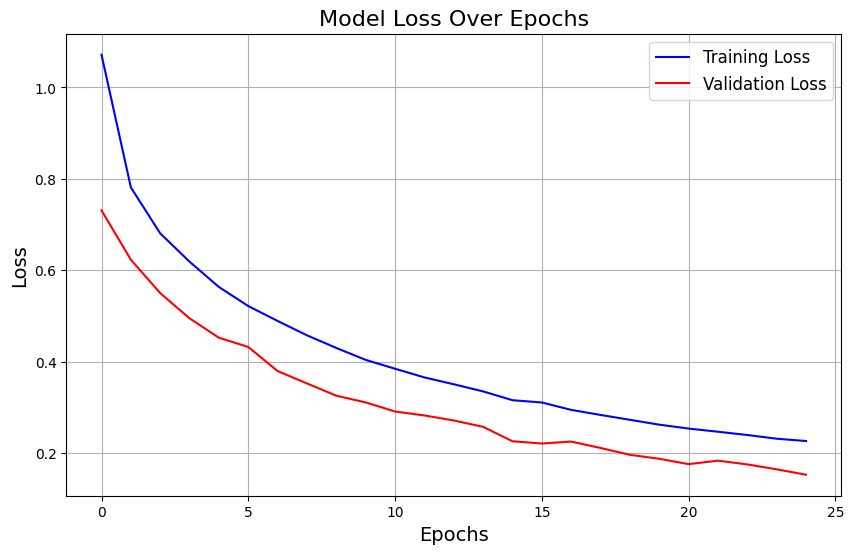

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()